In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import plotly.express as px
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv('/content/Bullying_2018.csv', sep=';')

In [ ]:
df.head(10)

,record,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Most_of_the_time_or_always_felt_lonely,Missed_classes_or_school_without_permission,Were_underweight,Were_overweight,Were_obese
0,1,Yes,Yes,,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,,,
1,2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,,,
2,3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
3,4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,,No,No,No,No,No
4,5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,,,
5,6,No,No,No,13 years old,Male,0 times,1 time,Never,3 or more,0 days,Most of the time,Always,No,No,No,No,No
6,7,No,No,No,14 years old,Female,1 time,0 times,Sometimes,3 or more,0 days,Most of the time,Always,No,No,,,
7,8,No,No,No,12 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Never,No,No,,,
8,9,No,No,No,13 years old,Male,1 time,2 or 3 times,Never,3 or more,6 to 9 days,Most of the time,Most of the time,No,Yes,,,
9,10,Yes,No,No,14 years old,Female,0 times,0 times,Always,0,0 days,Sometimes,Never,Yes,No,,,


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Data columns (total 18 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   record                                            56981 non-null  int64 
 1   Bullied_on_school_property_in_past_12_months      56981 non-null  object
 2   Bullied_not_on_school_property_in_past_12_months  56981 non-null  object
 3   Cyber_bullied_in_past_12_months                   56981 non-null  object
 4   Custom_Age                                        56981 non-null  object
 5   Sex                                               56981 non-null  object
 6   Physically_attacked                               56981 non-null  object
 7   Physical_fighting                                 56981 non-null  object
 8   Felt_lonely                                       56981 non-null  object
 9   Close_friends               

In [ ]:
df.shape

(56981, 18)

In [ ]:
df.isnull().sum()

,0
record,0
Bullied_on_school_property_in_past_12_months,0
Bullied_not_on_school_property_in_past_12_months,0
Cyber_bullied_in_past_12_months,0
Custom_Age,0
Sex,0
Physically_attacked,0
Physical_fighting,0
Felt_lonely,0
Close_friends,0


In [ ]:
df['Were_overweight'].unique()

array([' ', 'No', 'Yes'], dtype=object)

In [ ]:
df = df.replace(' ', np.nan)

In [ ]:
df.isnull().sum()

,0
record,0
Bullied_on_school_property_in_past_12_months,1239
Bullied_not_on_school_property_in_past_12_months,489
Cyber_bullied_in_past_12_months,571
Custom_Age,108
Sex,536
Physically_attacked,240
Physical_fighting,268
Felt_lonely,366
Close_friends,1076


In [ ]:
df.head(10)

,record,Bullied_on_school_property_in_past_12_months,Bullied_not_on_school_property_in_past_12_months,Cyber_bullied_in_past_12_months,Custom_Age,Sex,Physically_attacked,Physical_fighting,Felt_lonely,Close_friends,Miss_school_no_permission,Other_students_kind_and_helpful,Parents_understand_problems,Most_of_the_time_or_always_felt_lonely,Missed_classes_or_school_without_permission,Were_underweight,Were_overweight,Were_obese
0,1,Yes,Yes,NaN,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,NaN,NaN,NaN
1,2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,NaN,NaN,NaN
2,3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
3,4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,NaN,No,No,No,No,No
4,5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,NaN,NaN,NaN
5,6,No,No,No,13 years old,Male,0 times,1 time,Never,3 or more,0 days,Most of the time,Always,No,No,No,No,No
6,7,No,No,No,14 years old,Female,1 time,0 times,Sometimes,3 or more,0 days,Most of the time,Always,No,No,NaN,NaN,NaN
7,8,No,No,No,12 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Never,No,No,NaN,NaN,NaN
8,9,No,No,No,13 years old,Male,1 time,2 or 3 times,Never,3 or more,6 to 9 days,Most of the time,Most of the time,No,Yes,NaN,NaN,NaN
9,10,Yes,No,No,14 years old,Female,0 times,0 times,Always,0,0 days,Sometimes,Never,Yes,No,NaN,NaN,NaN


Rename DataSet

In [ ]:
df.rename(columns={'Bullied_on_school_property_in_past_12_months' : 'Bullied_on_school',
                    'Bullied_not_on_school_property_in_past_12_months' : 'Bullied_out_school',
                    'Cyber_bullied_in_past_12_months' : 'Cyber_bullied',
                    'Custom_Age' : 'Age',
                    'Physically_attacked' : 'Attacked',
                    'Physical_fighting' : 'Fighting',
                    'Miss_school_no_permission' : 'Missed_school',
                    'Other_students_kind_and_helpful' : 'Peers_kind_helpful',
                    'Parents_understand_problems' : 'Aware_Parents',
                    'Missed_classes_or_school_without_permission'	: 'Missed_classes'
                     }, inplace=True)

In [ ]:
df.head()

,record,Bullied_on_school,Bullied_out_school,Cyber_bullied,Age,Sex,Attacked,Fighting,Felt_lonely,Close_friends,Missed_school,Peers_kind_helpful,Aware_Parents,Most_of_the_time_or_always_felt_lonely,Missed_classes,Were_underweight,Were_overweight,Were_obese
0,1,Yes,Yes,NaN,13 years old,Female,0 times,0 times,Always,2,10 or more days,Never,Always,Yes,Yes,NaN,NaN,NaN
1,2,No,No,No,13 years old,Female,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,NaN,NaN,NaN
2,3,No,No,No,14 years old,Male,0 times,0 times,Never,3 or more,0 days,Sometimes,Always,No,No,No,No,No
3,4,No,No,No,16 years old,Male,0 times,2 or 3 times,Never,3 or more,0 days,Sometimes,NaN,No,No,No,No,No
4,5,No,No,No,13 years old,Female,0 times,0 times,Rarely,3 or more,0 days,Most of the time,Most of the time,No,No,NaN,NaN,NaN


#Handling NaN

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(32938, 18)

#Encoding

In [ ]:
df.nunique()

,0
record,32938
Bullied_on_school,2
Bullied_out_school,2
Cyber_bullied,2
Age,8
Sex,2
Attacked,8
Fighting,8
Felt_lonely,5
Close_friends,4


Mapping


In [ ]:
df['Bullied_on_school'] = df['Bullied_on_school'].map({'Yes':1, 'No': 0})
df['Bullied_out_school'] = df['Bullied_out_school'].map({'Yes':1, 'No': 0})
df['Cyber_bullied'] = df['Cyber_bullied'].map({'Yes':1, 'No': 0})

In [ ]:
df['Age'].head()

,Age
2,14 years old
5,13 years old
10,15 years old
22,13 years old
23,14 years old


In [ ]:
df['Age'] = df['Age'].str.extract('(\d+)').astype(int)

In [ ]:
df['Sex'] = df['Sex'].map({'Female':0, 'Male':1})

In [ ]:
df['Attacked'].unique()

array(['0 times', '1 time', '4 or 5 times', '10 or 11 times',
       '2 or 3 times', '12 or more times', '6 or 7 times', '8 or 9 times'],
      dtype=object)

In [ ]:
df['Attacked'] = df['Attacked'].map({'0 times' : 0, '1 time' : 1, '4 or 5 times' : 4, '10 or 11 times' : 10,
                                    '2 or 3 times' : 2, '12 or more times' : 12, '6 or 7 times' : 6, '8 or 9 times' : 8

})

In [ ]:
df['Fighting'].unique()

array(['0 times', '1 time', '2 or 3 times', '8 or 9 times',
       '4 or 5 times', '6 or 7 times', '10 or 11 times',
       '12 or more times'], dtype=object)

In [ ]:
df['Fighting'] = df['Fighting'].map({'0 times' : 0, '1 time' : 1, '2 or 3 times' : 2, '8 or 9 times' : 8,
       '4 or 5 times' : 4, '6 or 7 times' : 6 , '10 or 11 times' : 10,
       '12 or more times' : 12})

In [ ]:
df['Felt_lonely'].unique()

array(['Never', 'Most of the time', 'Rarely', 'Sometimes', 'Always'],
      dtype=object)

In [ ]:
df['Felt_lonely'] = df['Felt_lonely'].map({'Never' : 'No', 'Most of the time' : 'Yes', 'Rarely' : 'No', 'Sometimes' : 'No', 'Always' : 'Yes'})
df['Felt_lonely'] = df['Felt_lonely'].map({'Yes' :  1, 'No' : 0})

pd get dummies felt_lonely

In [ ]:
df['Close_friends'].unique()

array(['3 or more', '2', '0', '1'], dtype=object)

In [ ]:
df['Close_friends'] = df['Close_friends'].map({'3 or more' : 3, '2' : 2, '0' : 0, '1' : 1})

In [ ]:
df['Missed_school'].unique()

array(['0 days', '3 to 5 days', '10 or more days', '1 or 2 days',
       '6 to 9 days'], dtype=object)

In [ ]:
df['Missed_school_mean'] = df['Missed_school'].map({'0 days' : 0, '3 to 5 days' : 4, '10 or more days' : 10, '1 or 2 days': 1.5,
                                                    '6 to 9 days' : 7.5})

In [ ]:
df.drop(columns='Missed_school', inplace=True)

In [ ]:
df['Peers_kind_helpful'].unique()

array(['Sometimes', 'Most of the time', 'Rarely', 'Always', 'Never'],
      dtype=object)

In [ ]:
df['Peers_kind_helpful'] = df['Peers_kind_helpful'].map({'Sometimes' : 'Yes', 'Most of the time' : 'Yes', 'Rarely' : 'Yes', 'Always' : 'Yes', 'Never' : 'No'})
df['Peers_kind_helpful'] = df['Peers_kind_helpful'].map({'Yes': 1, 'No' : 0})

In [ ]:
df['Aware_Parents'].unique()

array(['Always', 'Sometimes', 'Rarely', 'Most of the time', 'Never'],
      dtype=object)

In [ ]:
df['Aware_Parents'] = df['Aware_Parents'].map({'Sometimes' : 'Yes', 'Most of the time' : 'Yes', 'Rarely' : 'No', 'Always' : 'Yes', 'Never' : 'No'})
df['Aware_Parents'] = df['Aware_Parents'].map({'Yes' : 1, 'No' : 0})

In [ ]:
df['Most_of_the_time_or_always_felt_lonely'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df.drop(columns='Most_of_the_time_or_always_felt_lonely', inplace=True)

In [ ]:
df['Missed_classes'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['Missed_classes'] = df['Missed_classes'].map({'Yes' : 1, 'No' : 0})

In [ ]:
df['Were_underweight'] = df['Were_underweight'].map({'Yes' : 1, 'No' : 0})
df['Were_overweight'] = df['Were_overweight'].map({'Yes' : 1, 'No' : 0})
df['Were_obese'] = df['Were_obese'].map({'Yes' : 1, 'No' : 0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32938 entries, 2 to 56980
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record              32938 non-null  int64  
 1   Bullied_on_school   32938 non-null  int64  
 2   Bullied_out_school  32938 non-null  int64  
 3   Cyber_bullied       32938 non-null  int64  
 4   Age                 32938 non-null  int64  
 5   Sex                 32938 non-null  int64  
 6   Attacked            32938 non-null  int64  
 7   Fighting            32938 non-null  int64  
 8   Felt_lonely         32938 non-null  int64  
 9   Close_friends       32938 non-null  int64  
 10  Peers_kind_helpful  32938 non-null  int64  
 11  Aware_Parents       32938 non-null  int64  
 12  Missed_classes      32938 non-null  int64  
 13  Were_underweight    32938 non-null  int64  
 14  Were_overweight     32938 non-null  int64  
 15  Were_obese          32938 non-null  int64  
 16  Missed_sc

EDA

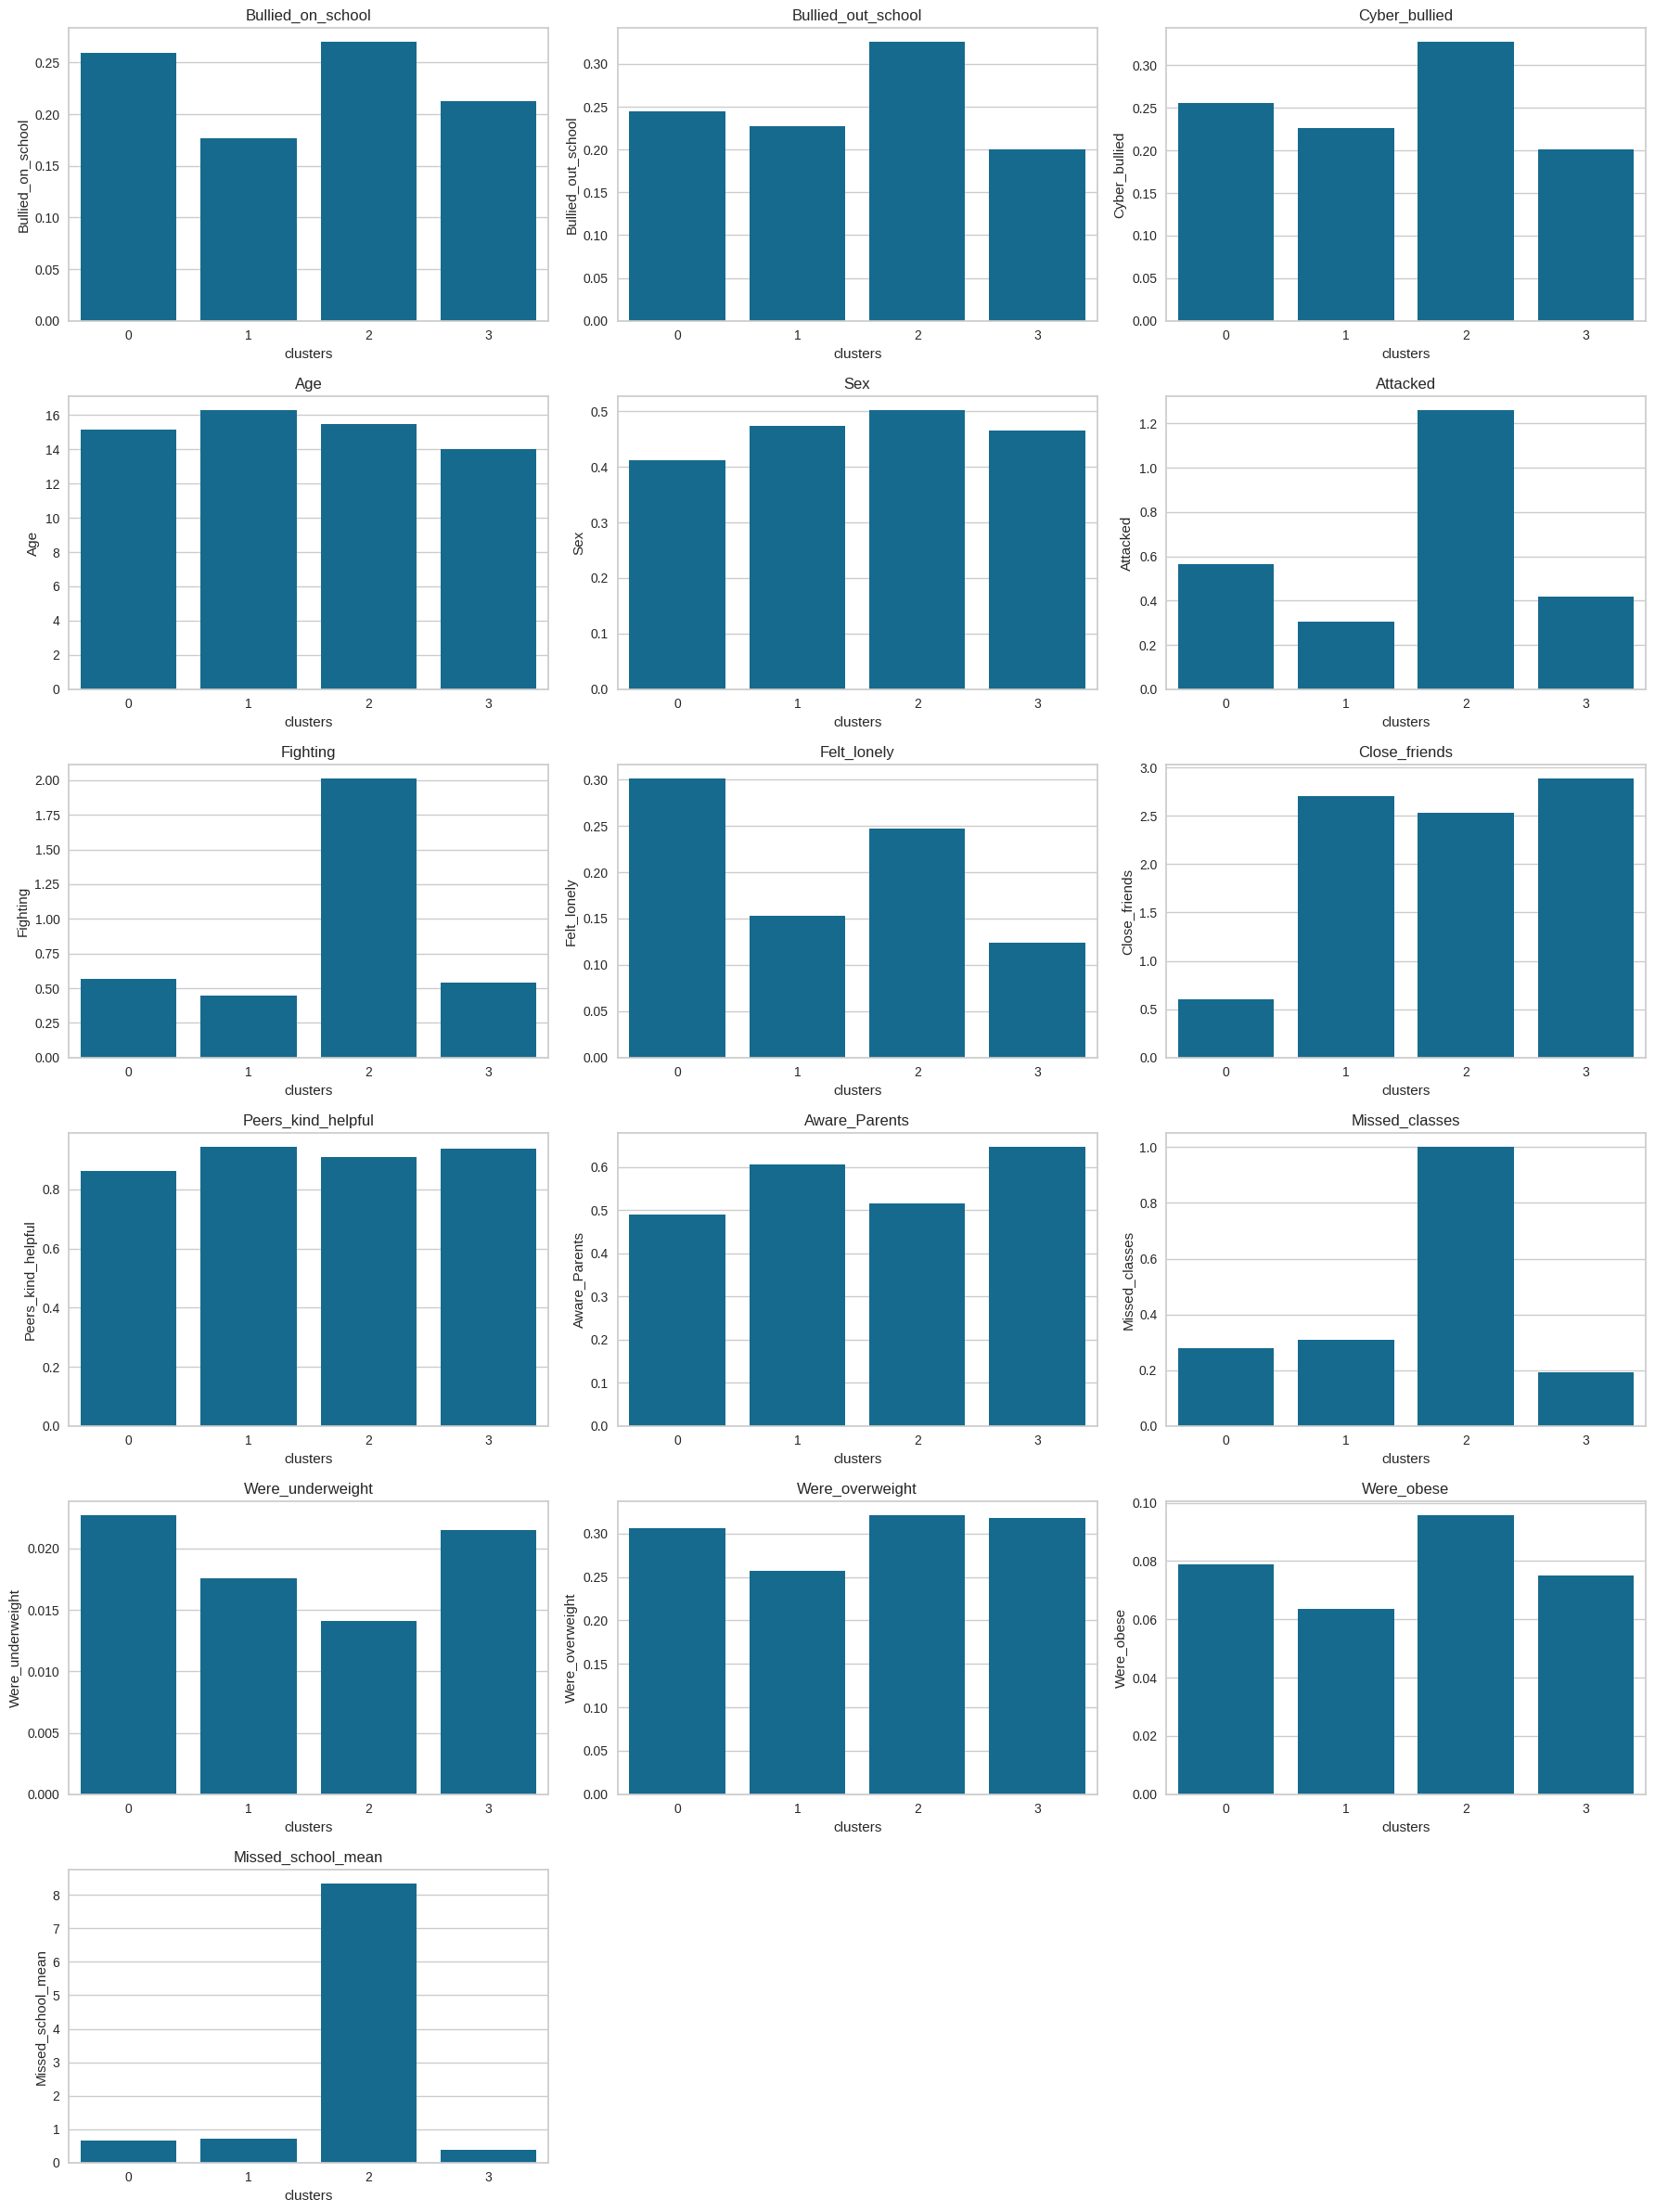

In [ ]:
cols = [c for c in df.columns if c not in ['record', 'clusters', 'clusters_labels']]

plt.figure(figsize=(18, 4 * (len(cols)//3 + 1)))

for i, c in enumerate(cols, 1):
    plt.subplot(len(cols)//3 + 1, 3, i)
    sns.barplot(data=df, x='clusters', y=c, ci=None)
    plt.title(c)

plt.tight_layout()
plt.show()


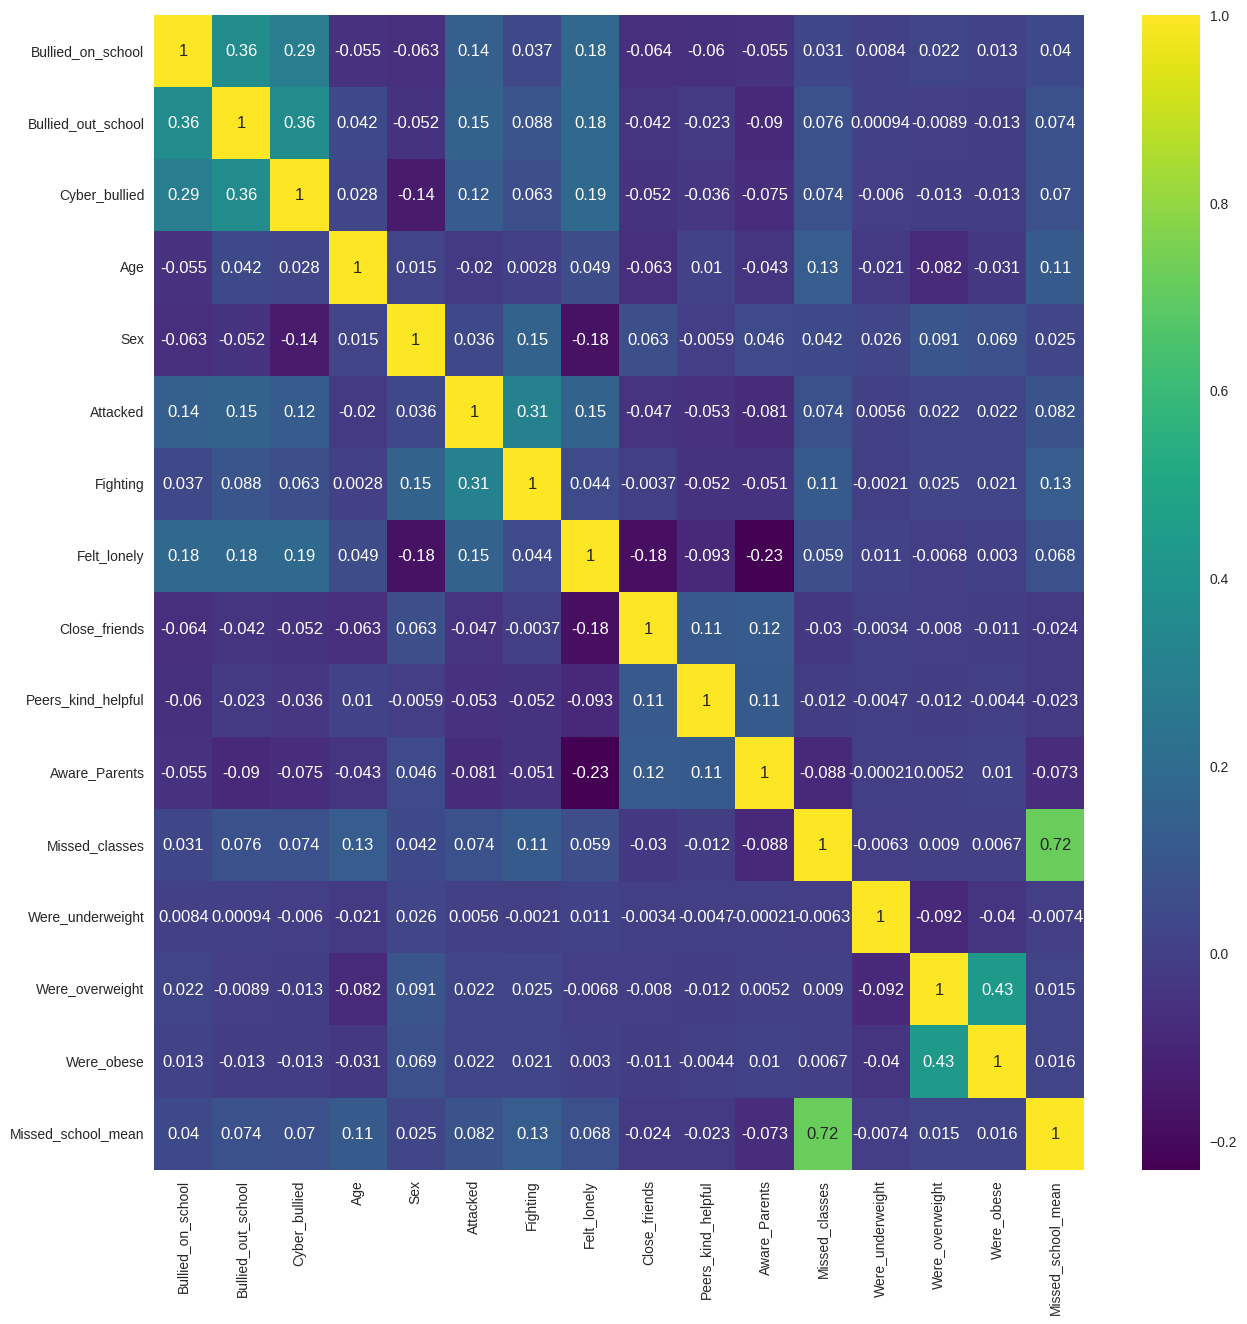

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df.drop(columns='record').corr(), annot=True, cmap='viridis')
plt.show()

#Scaling

MinMaxScaler

In [ ]:
df.nunique()

,0
record,32938
Bullied_on_school,2
Bullied_out_school,2
Cyber_bullied,2
Age,8
Sex,2
Attacked,8
Fighting,8
Felt_lonely,2
Close_friends,4


In [ ]:
cols_to_scale = ['Age','Attacked','Fighting','Close_friends','Missed_school_mean']

In [ ]:
mm= MinMaxScaler()

In [ ]:
df_scaled = df.copy()

In [ ]:
df_scaled[cols_to_scale] = mm.fit_transform(df_scaled[cols_to_scale])

In [ ]:
df_scaled.head()

,record,Bullied_on_school,Bullied_out_school,Cyber_bullied,Age,Sex,Attacked,Fighting,Felt_lonely,Close_friends,Peers_kind_helpful,Aware_Parents,Missed_classes,Were_underweight,Were_overweight,Were_obese,Missed_school_mean
2,3,0,0,0,0.428571,1,0.0,0.000000,0,1.000000,1,1,0,0,0,0,0.0
5,6,0,0,0,0.285714,1,0.0,0.083333,0,1.000000,1,1,0,0,0,0,0.0
10,11,0,0,0,0.571429,1,0.0,0.083333,0,1.000000,1,1,1,0,0,0,0.4
22,23,0,0,1,0.285714,1,0.0,0.166667,1,1.000000,1,1,0,0,0,0,0.0
23,24,0,0,0,0.428571,1,0.0,0.166667,1,0.666667,1,1,0,0,1,1,0.0


In [ ]:
df_scaled.drop(columns='record', inplace=True)

In [ ]:
df_scaled.shape

(32938, 16)

#PCA

In [ ]:
pca = PCA()

In [ ]:
df_pca = pca.fit(df_scaled)

In [ ]:
pca.explained_variance_ratio_

array([0.18287597, 0.13818274, 0.12285647, 0.11460722, 0.10627229,
       0.06345208, 0.05954065, 0.05444823, 0.04027471, 0.03273113,
       0.02657385, 0.01869928, 0.01278444, 0.01008969, 0.00975326,
       0.00685797])

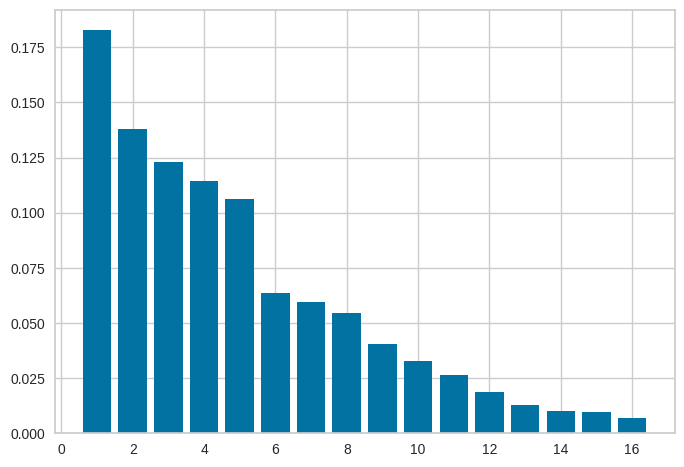

In [ ]:
plt.bar(range(1, len(pca.explained_variance_ratio_) +1), pca.explained_variance_ratio_)
plt.show()

In [ ]:
print('Percentage of cumulative variance of PCs', pca.explained_variance_ratio_.cumsum()*100)

Percentage of cumulative variance of PCs [ 18.28759733  32.1058715   44.39151899  55.85224142  66.47947034
  72.82467839  78.77874332  84.22356632  88.25103703  91.52415032
  94.18153521  96.05146354  97.32990724  98.33887674  99.3142026
 100.        ]


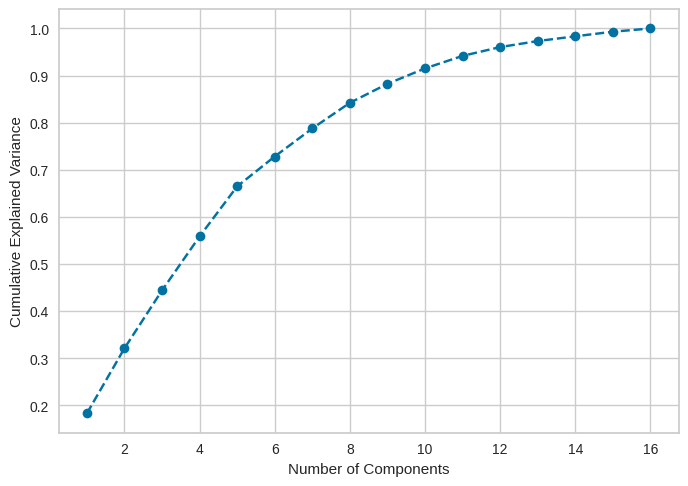

In [ ]:
plt.plot(range(1, pca.n_components_+1), np.cumsum(pca.explained_variance_ratio_), marker = 'o', linestyle = '--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [ ]:
pca = PCA(n_components=3)


df_pca = pca.fit_transform(df_scaled[cols_to_scale])
df_pca = pd.DataFrame(df_pca, columns=['PC1','PC2','PC3'], index=df.index)

In [ ]:
df_pca.head()

,PC1,PC2,PC3
2,0.181633,-0.143084,-0.079058
5,0.192670,-0.186549,-0.221883
10,0.149173,0.284874,-0.110673
22,0.191918,-0.172500,-0.235616
23,-0.151488,-0.142434,-0.123510


#Elbow Method

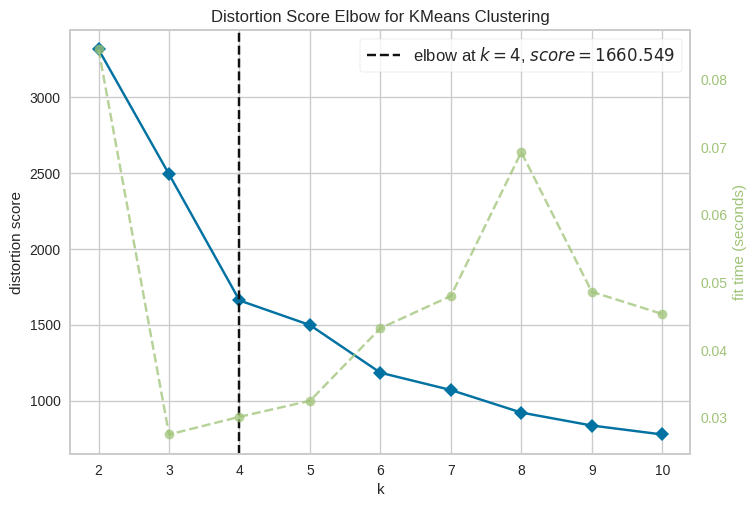

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
Elbow = KElbowVisualizer(estimator=KMeans(), k=10)
Elbow.fit(df_pca)
Elbow.show()

#KMeans

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

In [ ]:
kmeans.fit(df_pca)

KMeans(n_clusters=4, random_state=42)

In [ ]:
df['clusters'] = kmeans.labels_

In [ ]:
cluster1 = df[df['clusters'] == 0]
cluster2 = df[df['clusters'] == 1]
cluster3 = df[df['clusters'] == 2]
cluster4 = df[df['clusters'] == 3]

In [ ]:
df_pca.head()

,PC1,PC2,PC3
2,0.181633,-0.143084,-0.079058
5,0.192670,-0.186549,-0.221883
10,0.149173,0.284874,-0.110673
22,0.191918,-0.172500,-0.235616
23,-0.151488,-0.142434,-0.123510


In [ ]:
df_pca['clusters'] = df['clusters']

In [ ]:
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
                    color='clusters', title='KMeans (4 clusters) pe componentele PCA (3D)')
fig.show()

#statistics on df intial

In [ ]:
clusters_statistics = df.groupby('clusters')[df.drop(columns=['record','clusters']).columns].agg(['mean','median','std'])
clusters_statistics

Bullied_on_school                  Bullied_out_school         \
                      mean median       std               mean median   
clusters                                                                
0                 0.259452    0.0  0.438386           0.244329    0.0   
1                 0.176372    0.0  0.381152           0.227124    0.0   
2                 0.269795    0.0  0.443983           0.325513    0.0   
3                 0.212781    0.0  0.409288           0.200066    0.0   

                   Cyber_bullied                         Age                   \
               std          mean median       std       mean median       std   
clusters                                                                        
0         0.429739      0.255907    0.0  0.436422  15.159735   15.0  1.351139   
1         0.418991      0.226620    0.0  0.418662  16.271154   16.0  0.674256   
2         0.468704      0.327273    0.0  0.469355  15.482698   16.0  1.285012   
3         0.400063      0.201457    0.0  0.401102  14.004636   14.0  0.795613   

               Sex                   Attacked                   Fighting  \
              mean median       std      mean median       std      mean   
clusters                                                                   
0         0.411626    0.0  0.492186  0.566399    0.0  1.882971  0.566635   
1         0.473658    0.0  0.499327  0.303840    0.0  1.147717  0.447525   
2         0.501466    1.0  0.500145  1.259238    0.0  2.966105  2.010557   
3         0.465232    0.0  0.498806  0.419007    0.0  1.570051  0.541192   

                          Felt_lonely                  Close_friends         \
         median       std        mean median       std          mean median   
clusters                                                                      
0           0.0  1.810002    0.300803    0.0  0.458662      0.599244    1.0   
1           0.0  1.430005    0.153348    0.0  0.360338      2.708092    3.0   
2           0.0  3.599019    0.247507    0.0  0.431691      2.534897    3.0   
3           0.0  1.614873    0.123841    0.0  0.329411      2.883179    3.0   

                   Peers_kind_helpful                  Aware_Parents         \
               std               mean median       std          mean median   
clusters                                                                      
0         0.490110           0.862949    1.0  0.343942      0.489367    0.0   
1         0.454659           0.942778    1.0  0.232276      0.606504    1.0   
2         0.790263           0.910850    1.0  0.285043      0.514370    1.0   
3         0.321218           0.938742    1.0  0.239811      0.645762    1.0   

                   Missed_classes                  Were_underweight         \
               std           mean median       std             mean median   
clusters                                                                     
0         0.499946       0.277174    0.0  0.447656         0.022684    0.0   
1         0.488546       0.310058    0.0  0.462536         0.017562    0.0   
2         0.499940       1.000000    1.0  0.000000         0.014076    0.0   
3         0.478298       0.192318    0.0  0.394134         0.021523    0.0   

                   Were_overweight                  Were_obese         \
               std            mean median       std       mean median   
clusters                                                                
0         0.148913        0.306711    0.0  0.461183   0.078922    0.0   
1         0.131357        0.257037    0.0  0.437018   0.063608    0.0   
2         0.117840        0.320821    0.0  0.466929   0.095601    0.0   
3         0.145125        0.318212    0.0  0.465798   0.074967    0.0   

                   Missed_school_mean                   
               std               mean median       std  
clusters                                                
0         0.269650           0.647448    0.0  1.300963  
1

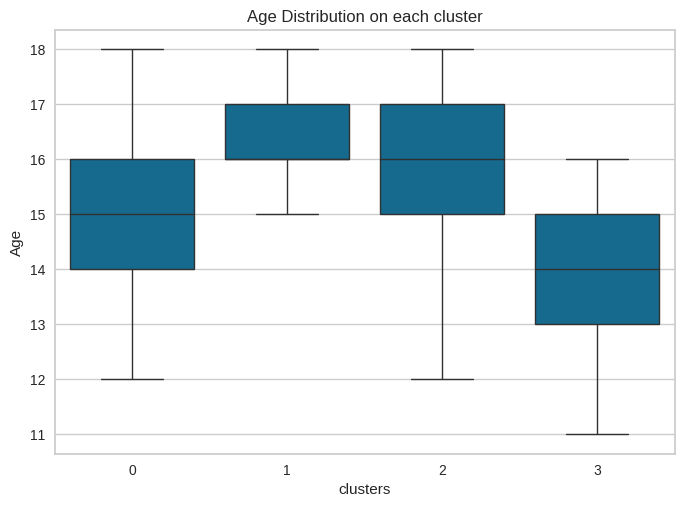

In [ ]:
sns.boxplot(x='clusters', y='Age', data=df)
plt.title('Age Distribution on each cluster')
plt.show()

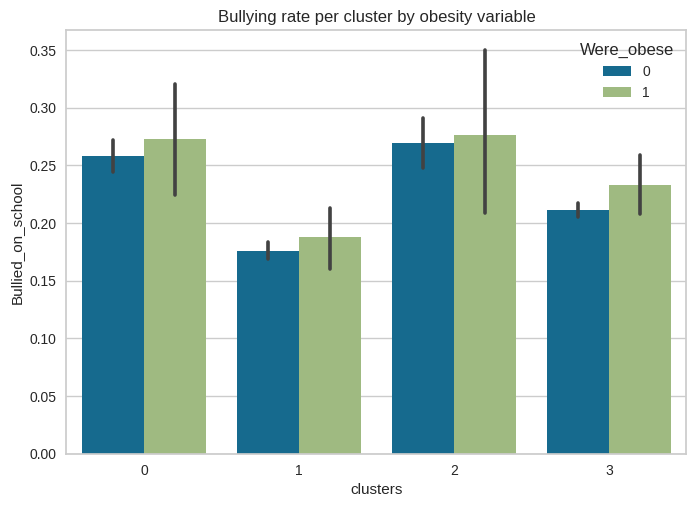

In [ ]:
sns.barplot(x='clusters', y='Bullied_on_school', hue='Were_obese', data=df)
plt.title('Bullying rate per cluster by obesity variable')
plt.show()

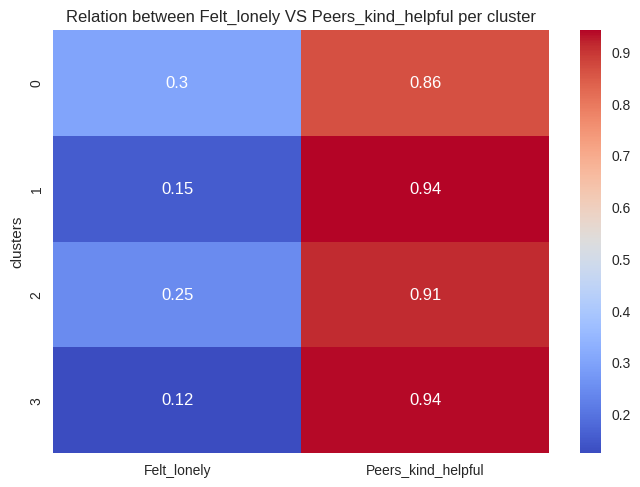

In [ ]:
sns.heatmap(df.groupby('clusters')[['Felt_lonely', 'Peers_kind_helpful']].mean(), annot=True, cmap='coolwarm')
plt.title('Relation between Felt_lonely VS Peers_kind_helpful per cluster')
plt.show()

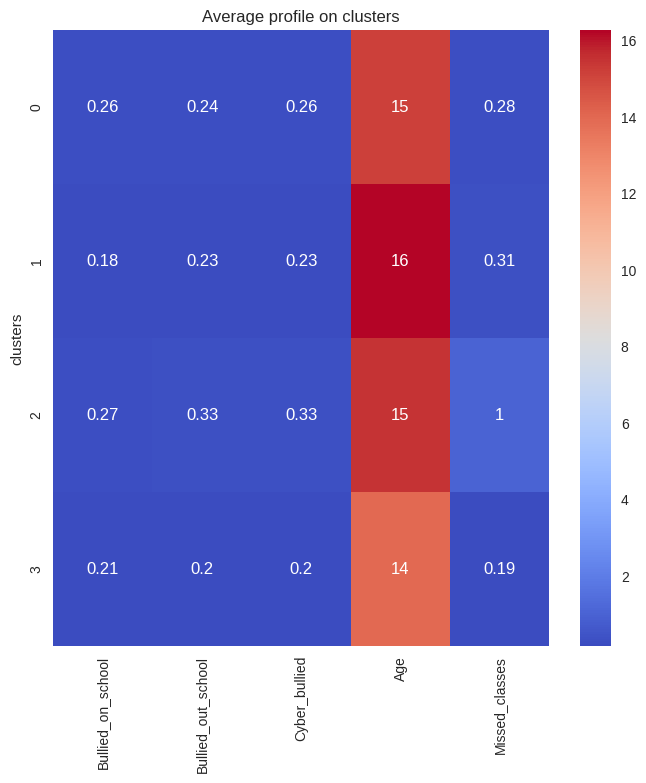

In [ ]:
plt.figure(figsize=(8,8))

sns.heatmap(df.groupby('clusters')[['Bullied_on_school',	'Bullied_out_school',	'Cyber_bullied',	'Age','Missed_classes']].mean(), annot=True, cmap='coolwarm')
plt.title('Average profile on clusters')
plt.show()

Check the quality of clusterning
⚙️ Interpretare:

0.7–1.0 → Clustere foarte bine separate

0.5–0.7 → Bine

0.25–0.5 → Slab/moderat

<0.25 → Probabil clustere neclare

In [ ]:
silhouette_avg = silhouette_score(df_pca, df['clusters'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

Silhouette Score: 0.792


Checking the balance of clusters

In [ ]:
df['clusters'].value_counts()

,count
clusters,
3,15100
1,11901
0,4232
2,1705


Comparative Analysis on cluster 2
*   Check if it's an ''extreme group'' or an arthefact








In [ ]:
df.groupby('clusters')[['Bullied_on_school','Fighting','Missed_school_mean','Felt_lonely']].mean()

,Bullied_on_school,Fighting,Missed_school_mean,Felt_lonely
clusters,,,,
0,0.259452,0.566635,0.647448,0.300803
1,0.176372,0.447525,0.723048,0.153348
2,0.269795,2.010557,8.332845,0.247507
3,0.212781,0.541192,0.378543,0.123841


In [ ]:
df.groupby('clusters')[['Cyber_bullied','Aware_Parents','Peers_kind_helpful','Were_overweight']].mean()

,Cyber_bullied,Aware_Parents,Peers_kind_helpful,Were_overweight
clusters,,,,
0,0.255907,0.489367,0.862949,0.306711
1,0.226620,0.606504,0.942778,0.257037
2,0.327273,0.514370,0.910850,0.320821
3,0.201457,0.645762,0.938742,0.318212


Labels per clusters

In [ ]:
clusters_labels = {
                        0: 'Moderate-Risk / Occasionally Involved',
                        1: 'Low-Risk / Well-Adjusted Students',
                        2: 'High-Risk / Violent & Absent Students',
                        3: 'Well-Integrated / Low-Conflict Students'
}

In [ ]:
df['clusters_labels'] = df['clusters'].map(clusters_labels)

In [ ]:
df.head()

,record,Bullied_on_school,Bullied_out_school,Cyber_bullied,Age,Sex,Attacked,Fighting,Felt_lonely,Close_friends,Peers_kind_helpful,Aware_Parents,Missed_classes,Were_underweight,Were_overweight,Were_obese,Missed_school_mean,clusters,clusters_labels
2,3,0,0,0,14,1,0,0,0,3,1,1,0,0,0,0,0.0,3,Well-Integrated / Low-Conflict Students
5,6,0,0,0,13,1,0,1,0,3,1,1,0,0,0,0,0.0,3,Well-Integrated / Low-Conflict Students
10,11,0,0,0,15,1,0,1,0,3,1,1,1,0,0,0,4.0,1,Low-Risk / Well-Adjusted Students
22,23,0,0,1,13,1,0,2,1,3,1,1,0,0,0,0,0.0,3,Well-Integrated / Low-Conflict Students
23,24,0,0,0,14,1,0,2,1,2,1,1,0,0,1,1,0.0,3,Well-Integrated / Low-Conflict Students


In [ ]:
print("""
Cluster Interpretation Summary:
- Cluster 0: Moderate-risk group with occasional bullying and fighting exposure.
- Cluster 1: Low-risk, emotionally stable and socially connected students.
- Cluster 2: High-risk group, high absenteeism, more violent behavior.
- Cluster 3: Well-integrated, emotionally balanced students with few issues.
- Cluster 4: Smaller, possibly isolated group with mixed or uncertain behavior patterns.

Silhouette Score indicates overall cluster separation quality.
""")



Cluster Interpretation Summary:
- Cluster 0: Moderate-risk group with occasional bullying and fighting exposure.
- Cluster 1: Low-risk, emotionally stable and socially connected students.
- Cluster 2: High-risk group, high absenteeism, more violent behavior.
- Cluster 3: Well-integrated, emotionally balanced students with few issues.
- Cluster 4: Smaller, possibly isolated group with mixed or uncertain behavior patterns.

Silhouette Score indicates overall cluster separation quality.

